# Experiment 0B — Original BGE Three-Way Benchmark

This experiment evaluates whether the original `BAAI/bge-base-en-v1.5` embedding model can distinguish PRO, CON, and NEUTRAL ballot leakage without task-specific fine-tuning.

The benchmark uses the same PRO, CON, and NEUTRAL semantic target banks used in the three-way fine-tuning experiments. Each validation sentence is embedded using the untouched BGE model and compared with the three target banks using cosine similarity.

The class with the highest maximum similarity is selected as the prediction.

No model fine-tuning, classifier training, triplet training, or threshold selection is performed.

**Research question:** How well does the original BGE embedding space distinguish PRO, CON, and NEUTRAL using semantic similarity alone?





In [1]:
!pip -q install -U sentence-transformers gspread scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 48.6 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gspread

from google.colab import auth
from google.auth import default

from sentence_transformers import SentenceTransformer

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

## Load Dataset

The same frozen TRAIN and VALIDATION splits used in the previous experiments are loaded.

TRAIN is not used to train or modify the model in this benchmark. It is loaded only to preserve and verify the existing experimental split.

TEST remains untouched.

In [3]:
auth.authenticate_user()

creds, _ = default()
gc = gspread.authorize(creds)

print("Google Sheets authentication successful.")

Google Sheets authentication successful.


In [4]:
SHEET_ID = "1HnVdDmYMZnnEDZANBYWM3RJ0w7WEpXQGZrCxWkyoqMQ"

spreadsheet = gc.open_by_key(SHEET_ID)

train_ws = spreadsheet.worksheet("TRAIN")
validation_ws = spreadsheet.worksheet("VALIDATION")

train_df = pd.DataFrame(train_ws.get_all_records())
validation_df = pd.DataFrame(validation_ws.get_all_records())

print("TRAIN rows:", len(train_df))
print("VALIDATION rows:", len(validation_df))

TRAIN rows: 285
VALIDATION rows: 61


In [5]:
for df in [train_df, validation_df]:
    df["leakage_direction"] = (
        df["leakage_direction"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

print("TRAIN label distribution:")
print(train_df["leakage_direction"].value_counts())

print("\nVALIDATION label distribution:")
print(validation_df["leakage_direction"].value_counts())

TRAIN label distribution:
leakage_direction
NEUTRAL    128
CON         93
PRO         64
Name: count, dtype: int64

VALIDATION label distribution:
leakage_direction
NEUTRAL    28
CON        19
PRO        14
Name: count, dtype: int64


## Verify Split

The existing judge-level split is preserved. TRAIN and VALIDATION should contain no overlapping judges, ballots, or sentence IDs.

In [6]:
train_judges = set(train_df["judge_id"].dropna())
validation_judges = set(validation_df["judge_id"].dropna())

train_ballots = set(train_df["ballot_id"].dropna())
validation_ballots = set(validation_df["ballot_id"].dropna())

train_sentence_ids = set(train_df["sentence_id"].dropna())
validation_sentence_ids = set(validation_df["sentence_id"].dropna())

judge_overlap = train_judges & validation_judges
ballot_overlap = train_ballots & validation_ballots
sentence_overlap = train_sentence_ids & validation_sentence_ids

print("Judge overlap:", len(judge_overlap))
print("Ballot overlap:", len(ballot_overlap))
print("Sentence ID overlap:", len(sentence_overlap))

assert len(judge_overlap) == 0
assert len(ballot_overlap) == 0
assert len(sentence_overlap) == 0

print("\nSplit verification passed.")

Judge overlap: 0
Ballot overlap: 0
Sentence ID overlap: 0

Split verification passed.


## Original BGE Model

The original `BAAI/bge-base-en-v1.5` model is loaded directly from Sentence Transformers.

No task-specific checkpoint is loaded and no model parameters are updated during this experiment.

In [7]:
MODEL_NAME = "BAAI/bge-base-en-v1.5"

base_model = SentenceTransformer(MODEL_NAME)

print("Loaded model:", MODEL_NAME)
print("Embedding dimension:", base_model.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded model: BAAI/bge-base-en-v1.5
Embedding dimension: 768


/tmp/ipykernel_1227/3629258972.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Embedding dimension:", base_model.get_sentence_embedding_dimension())


## Three-Way Semantic Targets

The benchmark uses the same PRO, CON, and NEUTRAL target definitions as the three-way fine-tuning experiments.

Keeping the target banks and inference procedure consistent allows the no-fine-tuning benchmark to be compared more directly with Experiments 2 and 3.

In [8]:
pro_targets = [
    "Pro wins the debate.",
    "The judge favors Pro over Con.",
    "Pro has the stronger argument than Con.",
    "Con fails against Pro's argument."
]

con_targets = [
    "Con wins the debate.",
    "The judge favors Con over Pro.",
    "Con has the stronger argument than Pro.",
    "Pro fails against Con's argument."
]

neutral_targets = [
    "This feedback does not indicate which side won.",
    "Neither side is clearly favored by this feedback.",
    "This is general feedback rather than a ballot decision.",
    "The sentence does not reveal the judge's vote."
]

print("PRO targets:", len(pro_targets))
print("CON targets:", len(con_targets))
print("NEUTRAL targets:", len(neutral_targets))

PRO targets: 4
CON targets: 4
NEUTRAL targets: 4


## Target Embeddings

Each semantic target is embedded using the untouched BGE model.

Embeddings are L2-normalized, so the dot product between two embeddings corresponds to cosine similarity.

In [9]:
pro_embeddings = base_model.encode(
    pro_targets,
    normalize_embeddings=True,
    show_progress_bar=False,
)

con_embeddings = base_model.encode(
    con_targets,
    normalize_embeddings=True,
    show_progress_bar=False,
)

neutral_embeddings = base_model.encode(
    neutral_targets,
    normalize_embeddings=True,
    show_progress_bar=False,
)

print("PRO target embeddings:", pro_embeddings.shape)
print("CON target embeddings:", con_embeddings.shape)
print("NEUTRAL target embeddings:", neutral_embeddings.shape)

PRO target embeddings: (4, 768)
CON target embeddings: (4, 768)
NEUTRAL target embeddings: (4, 768)


## Validation Sentence Embeddings

Only the sentence text is used as input, consistent with the sentence-only setup of the previous experiments.

No section, previous sentence, next sentence, ballot outcome, or other metadata is provided to the model.

In [10]:
validation_sentences = (
    validation_df["sentence"]
    .fillna("")
    .astype(str)
    .tolist()
)

validation_embeddings = base_model.encode(
    validation_sentences,
    normalize_embeddings=True,
    show_progress_bar=True,
)

print(
    "VALIDATION embeddings:",
    validation_embeddings.shape
)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

VALIDATION embeddings: (61, 768)


## Three-Way Similarity Scoring

For each validation sentence, cosine similarity is calculated against every target sentence in each semantic target bank.

The maximum similarity within each class is used as that class's score:

- `pro_score` = maximum similarity to any PRO target
- `con_score` = maximum similarity to any CON target
- `neutral_score` = maximum similarity to any NEUTRAL target

The class with the highest score becomes the prediction.

In [11]:
pro_similarity = (
    validation_embeddings
    @ pro_embeddings.T
)

con_similarity = (
    validation_embeddings
    @ con_embeddings.T
)

neutral_similarity = (
    validation_embeddings
    @ neutral_embeddings.T
)

validation_df["pro_score"] = (
    pro_similarity.max(axis=1)
)

validation_df["con_score"] = (
    con_similarity.max(axis=1)
)

validation_df["neutral_score"] = (
    neutral_similarity.max(axis=1)
)

display(
    validation_df[
        [
            "sentence",
            "leakage_direction",
            "pro_score",
            "con_score",
            "neutral_score",
        ]
    ].head()
)

,sentence,leakage_direction,pro_score,con_score,neutral_score
0,Needs more direct refutation of PRO’s economic...,PRO,0.669244,0.636196,0.648202
1,"Con2 also claims that STEMS are wasting money,...",PRO,0.571956,0.564920,0.555298
2,Con2 is also good at pointing out that Pro can...,CON,0.672565,0.662717,0.564018
3,Con also points out that proponents fail to gi...,CON,0.690540,0.684176,0.580430
4,"Overall speaking, con made more contributions ...",CON,0.695290,0.707542,0.576273


## Three-Way Prediction

Unlike the original threshold-based baseline, this benchmark does not use a manually selected threshold.

PRO, CON, and NEUTRAL are treated as three explicit semantic alternatives. The class with the highest similarity score is selected directly.

In [12]:
three_way_scores = np.column_stack([
    validation_df["pro_score"].to_numpy(),
    validation_df["con_score"].to_numpy(),
    validation_df["neutral_score"].to_numpy(),
])

LABELS_SCORE_ORDER = np.array([
    "PRO",
    "CON",
    "NEUTRAL",
])

validation_df["benchmark_prediction"] = (
    LABELS_SCORE_ORDER[
        np.argmax(
            three_way_scores,
            axis=1
        )
    ]
)

display(
    validation_df[
        [
            "sentence",
            "leakage_direction",
            "pro_score",
            "con_score",
            "neutral_score",
            "benchmark_prediction",
        ]
    ].head(10)
)

,sentence,leakage_direction,pro_score,con_score,neutral_score,benchmark_prediction
0,Needs more direct refutation of PRO’s economic...,PRO,0.669244,0.636196,0.648202,PRO
1,"Con2 also claims that STEMS are wasting money,...",PRO,0.571956,0.564920,0.555298,PRO
2,Con2 is also good at pointing out that Pro can...,CON,0.672565,0.662717,0.564018,PRO
3,Con also points out that proponents fail to gi...,CON,0.690540,0.684176,0.580430,PRO
4,"Overall speaking, con made more contributions ...",CON,0.695290,0.707542,0.576273,CON
5,"Both sides did a good job, but when compared, ...",CON,0.679380,0.653965,0.645863,PRO
6,"Therefore, I voted for the con side.",CON,0.637477,0.638956,0.619522,CON
7,Your strongest move was asking whether PRO cou...,CON,0.629957,0.607103,0.535539,PRO
8,I vote for CON.,CON,0.712331,0.715243,0.622322,CON
9,PRO explained well why childcare can reduce pr...,CON,0.555097,0.548803,0.564024,NEUTRAL


## Validation Evaluation

The untouched BGE benchmark is evaluated using the same core metrics as the three-way fine-tuning experiments:

- Overall three-way accuracy
- Macro-F1
- Per-class precision, recall, and F1
- Confusion matrix
- Leakage-only direction accuracy

In [13]:
y_true = (
    validation_df["leakage_direction"]
    .to_numpy()
)

y_pred = (
    validation_df["benchmark_prediction"]
    .to_numpy()
)

In [14]:
benchmark_accuracy = accuracy_score(
    y_true,
    y_pred
)

benchmark_macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(
    "Accuracy:",
    round(benchmark_accuracy, 4)
)

print(
    "Macro-F1:",
    round(benchmark_macro_f1, 4)
)

Accuracy: 0.4262
Macro-F1: 0.4272


In [15]:
REPORT_LABELS = [
    "CON",
    "NEUTRAL",
    "PRO",
]

print(
    classification_report(
        y_true,
        y_pred,
        labels=REPORT_LABELS,
        digits=3,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

         CON      0.538     0.368     0.438        19
     NEUTRAL      0.600     0.321     0.419        28
         PRO      0.303     0.714     0.426        14

    accuracy                          0.426        61
   macro avg      0.480     0.468     0.427        61
weighted avg      0.513     0.426     0.426        61



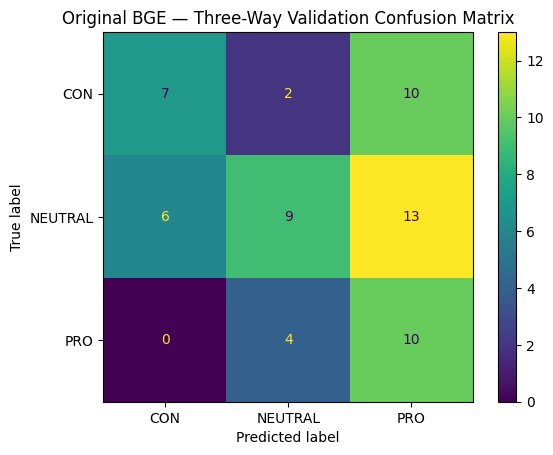

In [16]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=REPORT_LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=REPORT_LABELS
)

disp.plot()

plt.title(
    "Original BGE — Three-Way Validation Confusion Matrix"
)

plt.show()

### Leakage-Only Direction Accuracy

This metric evaluates directional discrimination specifically among validation sentences whose ground-truth label is PRO or CON.

A PRO or CON sentence predicted as NEUTRAL is counted as incorrect, as is a prediction in the opposite direction.

This isolates the model's ability to identify the correct direction of sentences that actually contain directional leakage.



In [17]:
directional_mask = np.isin(
    y_true,
    ["PRO", "CON"]
)

benchmark_directional_accuracy = (
    accuracy_score(
        y_true[directional_mask],
        y_pred[directional_mask],
    )
)

print(
    "Directional validation examples:",
    directional_mask.sum()
)

print(
    "Leakage-only direction accuracy:",
    round(
        benchmark_directional_accuracy,
        4
    )
)

Directional validation examples: 33
Leakage-only direction accuracy: 0.5152


In [18]:
print("Ground-truth distribution:")
print(
    pd.Series(y_true)
    .value_counts()
)

print("\nPrediction distribution:")
print(
    pd.Series(y_pred)
    .value_counts()
)

Ground-truth distribution:
NEUTRAL    28
CON        19
PRO        14
Name: count, dtype: int64

Prediction distribution:
PRO        33
NEUTRAL    15
CON        13
Name: count, dtype: int64


## Error Inspection

Misclassified validation examples are inspected to identify whether the untouched BGE model primarily struggles with:

1. distinguishing PRO from CON, or
2. distinguishing directional leakage from NEUTRAL feedback.

In [19]:
errors_df = validation_df[
    validation_df["leakage_direction"]
    != validation_df["benchmark_prediction"]
][
    [
        "sentence_id",
        "section",
        "sentence",
        "leakage_direction",
        "benchmark_prediction",
        "pro_score",
        "con_score",
        "neutral_score",
    ]
].copy()

print(
    "Validation errors:",
    len(errors_df)
)

display(errors_df)

Validation errors: 35


,sentence_id,section,sentence,leakage_direction,benchmark_prediction,pro_score,con_score,neutral_score
2,FA_R1_B2-304_S0031,Reason for Decision,Con2 is also good at pointing out that Pro can...,CON,PRO,0.672565,0.662717,0.564018
3,FA_R1_B2-304_S0033,Reason for Decision,Con also points out that proponents fail to gi...,CON,PRO,0.690540,0.684176,0.580430
5,FA_R2_B1-210_S0010,Reason for Decision,"Both sides did a good job, but when compared, ...",CON,PRO,0.679380,0.653965,0.645863
7,FA_R4_3129832024_S0005,Comments to CON,Your strongest move was asking whether PRO cou...,CON,PRO,0.629957,0.607103,0.535539
9,FA_R4_3129832024_S0008,Reason for Decision,PRO explained well why childcare can reduce pr...,CON,NEUTRAL,0.555097,0.548803,0.564024
10,FA_R4_3129832024_S0010,Reason for Decision,"Most importantly, CON directly challenged PRO’...",CON,PRO,0.661533,0.648391,0.592256
14,FB_R1_B1-209_S0031,Reason for Decision,"But even con win on this clash, but because of...",PRO,NEUTRAL,0.587278,0.592127,0.637722
18,FA_R1_301_S001,Comments to PRO,Strong emotional and human-centered framing (w...,NEUTRAL,PRO,0.611522,0.586361,0.484501
20,FA_R1_301_S007,Comments to PRO,Arguments turned into evidence stacking withou...,CON,PRO,0.593680,0.590442,0.573851
21,FA_R1_301_S010,Comments to CON,"Effective framing around survival (medicine, f...",NEUTRAL,PRO,0.586250,0.566428,0.492999


In [20]:
directional_errors_df = validation_df[
    validation_df["leakage_direction"]
    .isin(["PRO", "CON"])
    &
    (
        validation_df["leakage_direction"]
        != validation_df["benchmark_prediction"]
    )
][
    [
        "sentence_id",
        "section",
        "sentence",
        "leakage_direction",
        "benchmark_prediction",
        "pro_score",
        "con_score",
        "neutral_score",
    ]
].copy()

print(
    "Directional errors:",
    len(directional_errors_df)
)

display(directional_errors_df)

Directional errors: 16


,sentence_id,section,sentence,leakage_direction,benchmark_prediction,pro_score,con_score,neutral_score
2,FA_R1_B2-304_S0031,Reason for Decision,Con2 is also good at pointing out that Pro can...,CON,PRO,0.672565,0.662717,0.564018
3,FA_R1_B2-304_S0033,Reason for Decision,Con also points out that proponents fail to gi...,CON,PRO,0.690540,0.684176,0.580430
5,FA_R2_B1-210_S0010,Reason for Decision,"Both sides did a good job, but when compared, ...",CON,PRO,0.679380,0.653965,0.645863
7,FA_R4_3129832024_S0005,Comments to CON,Your strongest move was asking whether PRO cou...,CON,PRO,0.629957,0.607103,0.535539
9,FA_R4_3129832024_S0008,Reason for Decision,PRO explained well why childcare can reduce pr...,CON,NEUTRAL,0.555097,0.548803,0.564024
10,FA_R4_3129832024_S0010,Reason for Decision,"Most importantly, CON directly challenged PRO’...",CON,PRO,0.661533,0.648391,0.592256
14,FB_R1_B1-209_S0031,Reason for Decision,"But even con win on this clash, but because of...",PRO,NEUTRAL,0.587278,0.592127,0.637722
20,FA_R1_301_S007,Comments to PRO,Arguments turned into evidence stacking withou...,CON,PRO,0.593680,0.590442,0.573851
27,FA_R1_301_S023,Reason for Decision,Regarding Pro’s proposed solution—using AI to ...,CON,PRO,0.612517,0.604953,0.532361
28,FA_R1_301_S024,Reason for Decision,"Con won by providing clearer causal logic, by ...",CON,PRO,0.640334,0.636400,0.559661


## Comparison with Fine-Tuned Models

This benchmark provides a direct no-fine-tuning reference for the three-way semantic similarity method.

The target banks and three-way argmax inference procedure are held constant relative to Experiments 2 and 3. The primary methodological difference is whether BGE has undergone task-specific triplet fine-tuning.

This helps isolate the effect of fine-tuning on the embedding space.

In [21]:
comparison_df = pd.DataFrame([
    {
        "model": "Exp 1 — Bi-directional Benchmark",
        "accuracy": 0.6136,
        "macro_f1": 0.4762,
        "leakage_only_direction_accuracy":  0.2778,
    },
    {
        "model": "Exp 1 — Bi-directional fine-tuning",
        "accuracy": 0.6591,
        "macro_f1": 0.5515,
        "leakage_only_direction_accuracy": 0.3889,
    },
    {
        "model": "Original BGE — Three-Way Benchmark",
        "accuracy": benchmark_accuracy,
        "macro_f1": benchmark_macro_f1,
        "leakage_only_direction_accuracy":
            benchmark_directional_accuracy,
    },
    {
        "model": "Exp 2 — Three-Way Fine-Tuning",
        "accuracy": 0.7045,
        "macro_f1": 0.6250,
        "leakage_only_direction_accuracy": 0.6111,
    },
    {
        "model": "Exp 3 — Full-TRAIN Fine-Tuning",
        "accuracy": 0.7045,
        "macro_f1": 0.6351,
        "leakage_only_direction_accuracy": 0.5556,
    },
])

display(
    comparison_df.round(4)
)

,model,accuracy,macro_f1,leakage_only_direction_accuracy
0,Exp 1 — Bi-directional Benchmark,0.6136,0.4762,0.2778
1,Exp 1 — Bi-directional fine-tuning,0.6591,0.5515,0.3889
2,Original BGE — Three-Way Benchmark,0.4262,0.4272,0.5152
3,Exp 2 — Three-Way Fine-Tuning,0.7045,0.6250,0.6111
4,Exp 3 — Full-TRAIN Fine-Tuning,0.7045,0.6351,0.5556
